In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

from convolutions.models.lenet import LeNet
from convolutions.train import train

In [20]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

# our model uses sigmoid based activation
# large batches can cause issues while
# training in sigmoid
# ! IMP :
# If we want to use large batches we can switch to ReLU
# and use kaiming weights init instead of xavier
batch_size = 64
data_root = "../../data"

# FashionMNIST is 1x28x28 grayscale. ToImage() -> tensor,
# ToDtype(scale=True) maps uint8 [0,255] pixels to float32 [0,1].
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

train_dataset = datasets.FashionMNIST(
    root=data_root, train=True, download=True, transform=transform
)
test_dataset = datasets.FashionMNIST(
    root=data_root, train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"train: {len(train_dataset)} samples | test: {len(test_dataset)} samples")

using device: mps
train: 60000 samples | test: 10000 samples


In [21]:
# sanity check
X_batch, y_batch = next(iter(train_loader))
print("batch X shape:", X_batch.shape)  # [batch_size, 1, 28, 28]
print("batch y shape:", y_batch.shape)  # [batch_size]

batch X shape: torch.Size([64, 1, 28, 28])
batch y shape: torch.Size([64])


In [22]:
# Training
model = LeNet(num_classes=10)
model.apply_init((1, 1, 28, 28))
optimiser = torch.optim.SGD(model.parameters(), lr=0.3)
loss_fn = torch.nn.CrossEntropyLoss()
train(model, loss_fn, optimiser, train_loader, epochs=15, device=device)

>>> epoch : 0 | epoch loss (train) : 1.8364936432985863 >>>
>>> epoch : 1 | epoch loss (train) : 0.8081267114196505 >>>
>>> epoch : 2 | epoch loss (train) : 0.6577889919598728 >>>
>>> epoch : 3 | epoch loss (train) : 0.5886380369348059 >>>
>>> epoch : 4 | epoch loss (train) : 0.5350989747180868 >>>
>>> epoch : 5 | epoch loss (train) : 0.4955996818411579 >>>
>>> epoch : 6 | epoch loss (train) : 0.46284872433269963 >>>
>>> epoch : 7 | epoch loss (train) : 0.4387995413562128 >>>
>>> epoch : 8 | epoch loss (train) : 0.419246667293089 >>>
>>> epoch : 9 | epoch loss (train) : 0.4029037984671877 >>>
>>> epoch : 10 | epoch loss (train) : 0.3890324338063248 >>>
>>> epoch : 11 | epoch loss (train) : 0.37785880777563874 >>>
>>> epoch : 12 | epoch loss (train) : 0.36549931050522494 >>>
>>> epoch : 13 | epoch loss (train) : 0.35513115245332594 >>>
>>> epoch : 14 | epoch loss (train) : 0.34727010924392926 >>>


batch accuracy: 85.94%


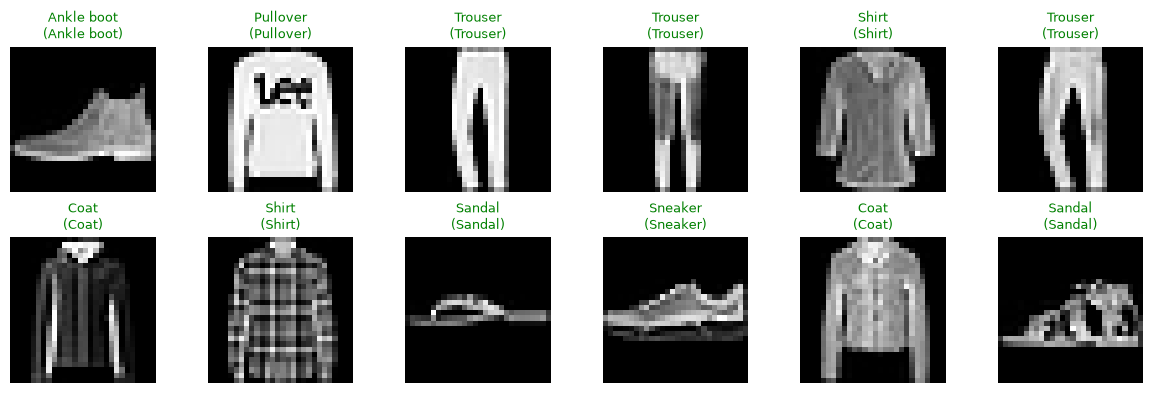

In [23]:
# Prediction on a test batch
import matplotlib.pyplot as plt

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

model.eval()
X_test, y_test = next(iter(test_loader))
X_test, y_test = X_test.to(device), y_test.to(device)

with torch.no_grad():
    logits = model(X_test)
    preds = logits.argmax(dim=1)

acc = (preds == y_test).float().mean().item()
print(f"batch accuracy: {acc:.2%}")

# show the first 12 with predicted vs true labels
n = 12
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    img = X_test[i].cpu().squeeze()
    pred, true = preds[i].item(), y_test[i].item()
    ax.imshow(img, cmap="gray")
    ax.set_title(
        f"{class_names[pred]}\n({class_names[true]})",
        color="green" if pred == true else "red",
        fontsize=9,
    )
    ax.axis("off")
plt.tight_layout()
plt.show()